In [1]:
# 성적 데이터 분석(통계)

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('score.csv')
df

,반,이름,국어,영어,수학,과학
0,1,성춘향,67,87,90,98
1,1,이몽룡,45,45,56,98
2,1,향단이,95,59,96,88
3,1,방자,65,94,89,98
4,1,월매,45,65,78,98
5,1,변학도,78,76,98,89
6,2,홍길동,87,67,65,56
7,2,임꺽정,89,98,78,78
8,2,전우치,100,78,56,65
9,2,일지매,99,89,87,87


In [5]:
subjects = [ '국어', '영어', '수학', '과학' ]

In [6]:
# df['추가할_컬럼명'] = 계산식
df['총점'] = df[ subjects ].sum(axis=1)
df

,반,이름,국어,영어,수학,과학,총점
0,1,성춘향,67,87,90,98,342
1,1,이몽룡,45,45,56,98,244
2,1,향단이,95,59,96,88,338
3,1,방자,65,94,89,98,346
4,1,월매,45,65,78,98,286
5,1,변학도,78,76,98,89,341
6,2,홍길동,87,67,65,56,275
7,2,임꺽정,89,98,78,78,343
8,2,전우치,100,78,56,65,299
9,2,일지매,99,89,87,87,362


In [7]:
df['평균'] = df[ subjects ].mean(axis=1)
df

,반,이름,국어,영어,수학,과학,총점,평균
0,1,성춘향,67,87,90,98,342,85.50
1,1,이몽룡,45,45,56,98,244,61.00
2,1,향단이,95,59,96,88,338,84.50
3,1,방자,65,94,89,98,346,86.50
4,1,월매,45,65,78,98,286,71.50
5,1,변학도,78,76,98,89,341,85.25
6,2,홍길동,87,67,65,56,275,68.75
7,2,임꺽정,89,98,78,78,343,85.75
8,2,전우치,100,78,56,65,299,74.75
9,2,일지매,99,89,87,87,362,90.50


In [8]:
df.sort_values(['평균'], ascending=[False])

,반,이름,국어,영어,수학,과학,총점,평균
9,2,일지매,99,89,87,87,362,90.50
3,1,방자,65,94,89,98,346,86.50
7,2,임꺽정,89,98,78,78,343,85.75
0,1,성춘향,67,87,90,98,342,85.50
5,1,변학도,78,76,98,89,341,85.25
2,1,향단이,95,59,96,88,338,84.50
11,2,콩쥐,65,89,87,78,319,79.75
8,2,전우치,100,78,56,65,299,74.75
4,1,월매,45,65,78,98,286,71.50
6,2,홍길동,87,67,65,56,275,68.75


In [9]:
# 한글깨짐 해결, 원인:디폴트 영문글꼴==>한글글꼴
import matplotlib.pyplot as plt
import platform
if platform.system() == 'Windows': # W:대문자
    plt.rcParams['font.family'] = 'Malgun Gothic' # M,G:대문자, 중간에 스페이스 한칸
elif platform.system() == 'Darwin': # 맥OS, D:대문자
    plt.rcParams['font.family'] = 'AppleGothic'
else: # 리눅스
    plt.rcParams['font.family'] = 'NanumGothic'
# -(마이너스 기호) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [10]:
sorted_df = df.sort_values(['평균'], ascending=[False])
sorted_df

,반,이름,국어,영어,수학,과학,총점,평균
9,2,일지매,99,89,87,87,362,90.50
3,1,방자,65,94,89,98,346,86.50
7,2,임꺽정,89,98,78,78,343,85.75
0,1,성춘향,67,87,90,98,342,85.50
5,1,변학도,78,76,98,89,341,85.25
2,1,향단이,95,59,96,88,338,84.50
11,2,콩쥐,65,89,87,78,319,79.75
8,2,전우치,100,78,56,65,299,74.75
4,1,월매,45,65,78,98,286,71.50
6,2,홍길동,87,67,65,56,275,68.75


In [11]:
sorted_df.index = sorted_df['이름']
sorted_df

,반,이름,국어,영어,수학,과학,총점,평균
이름,,,,,,,,
일지매,2,일지매,99,89,87,87,362,90.50
방자,1,방자,65,94,89,98,346,86.50
임꺽정,2,임꺽정,89,98,78,78,343,85.75
성춘향,1,성춘향,67,87,90,98,342,85.50
변학도,1,변학도,78,76,98,89,341,85.25
향단이,1,향단이,95,59,96,88,338,84.50
콩쥐,2,콩쥐,65,89,87,78,319,79.75
전우치,2,전우치,100,78,56,65,299,74.75
월매,1,월매,45,65,78,98,286,71.50


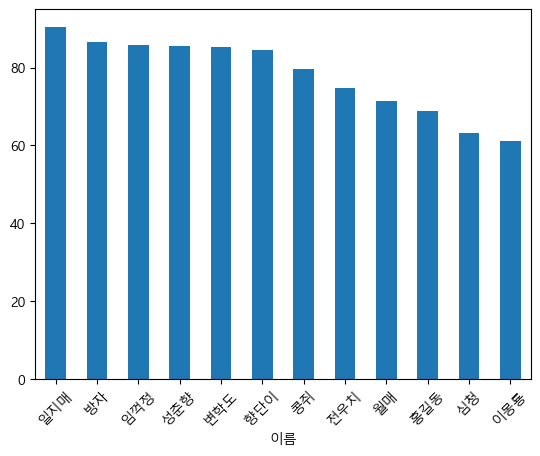

In [12]:
sorted_df['평균'].plot(kind='bar', rot=45)
plt.show()

In [13]:
ban1 = df[ df['반'] == 1 ]
ban2 = df[ df['반'] == 2 ]

In [14]:
ban1_mean = ban1['평균'].mean()
ban2_mean = ban2['평균'].mean()

In [15]:
ban1_mean, ban2_mean # (79.04166666666667, 77.125)

(79.04166666666667, 77.125)

In [16]:
from scipy import stats

In [17]:
stats.ttest_ind(ban1['평균'], ban2['평균'])

TtestResult(statistic=0.319960228209846, pvalue=0.7555833361856389, df=10.0)

In [18]:
for s in subjects: # [ '국어', '영어', '수학', '과학' ]
    print( s, stats.ttest_ind(ban1[s], ban2[s]) )

국어 TtestResult(statistic=-2.490140665442242, pvalue=0.03198249498381643, df=10.0)
영어 TtestResult(statistic=-0.6156907152631581, pvalue=0.5518533781528808, df=10.0)
수학 TtestResult(statistic=1.4961318778859336, pvalue=0.16549584200790557, df=10.0)
과학 TtestResult(statistic=4.328442555331755, pvalue=0.001493197771173248, df=10.0)


In [19]:
ban1['과학'].mean(), ban2['과학'].mean()

(94.83333333333333, 69.66666666666667)

In [20]:
# end